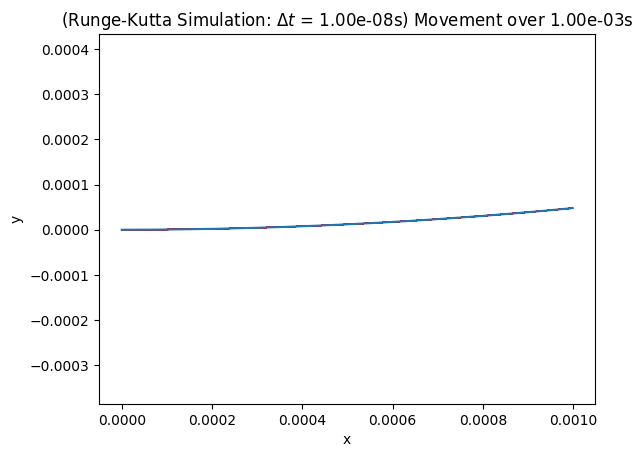

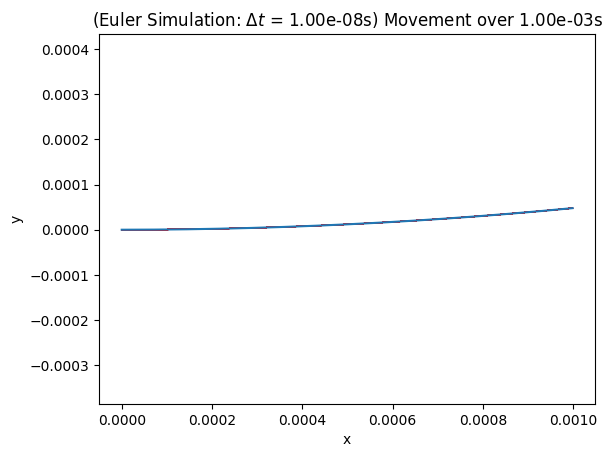

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def advance_time(r0, v0, dt):
    # define variables
    B = np.array([0, 0, -1e-6]) # T
    q = 1.602e-19 # C
    m = 1.673e-27 # kg
    a = (q/m)*np.cross(v0, B)
    v1 = np.add(v0, a*dt)
    r1 = np.add(r0, v0*dt)
    return r1, v1

def derivatives(r, v):
    B = np.array([0, 0, -1e-6])
    q = 1.602e-19
    m = 1.673e-27
    drdt = v
    dvdt = (q/m) * np.cross(v, B)
    return drdt, dvdt

def runge_kutta_simulate(r0, v0, dt, num_steps):
    r = r0
    v = v0
    t = 0
    traj_r = [r0]
    traj_v = [v0]
    for _ in range(num_steps):
        k1_r, k1_v = derivatives(r, v)
        k2_r, k2_v = derivatives(r + dt*k1_r/2, v + dt*k1_v/2)
        k3_r, k3_v = derivatives(r + dt*k2_r/2, v + dt*k2_v/2)
        k4_r, k4_v = derivatives(r + dt*k3_r,   v + dt*k3_v)

        ri = r + dt*(k1_r + 2*k2_r + 2*k3_r + k4_r)/6
        vi = v + dt*(k1_v + 2*k2_v + 2*k3_v + k4_v)/6

        traj_r.append(ri)
        traj_v.append(vi)
        r, v, t = ri, vi, t+dt
    
    r_path = np.array(traj_r)
    v_path = np.array(traj_v)

    x_positions = r_path[:, 0]
    y_positions = r_path[:, 1]
    u = v_path[:, 0]
    w = v_path[:, 1]

    plt.plot(x_positions, y_positions)
    plt.quiver(x_positions, y_positions, u, w, color='red')
    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(r'(Runge-Kutta Simulation: $\Delta t$ = ' + f'{dt:.2e}s) Movement over {dt*num_steps:.2e}s')
    plt.savefig('output-runge-kutta.png')
    plt.show()

def euler_simulate(r0, v0, dt, num_steps):
    r = r0
    v = v0
    traj_r = [r0]
    traj_v = [v0]
    for i in range(num_steps):
        ri, vi = advance_time(r, v, dt)
        traj_r.append(ri)
        traj_v.append(vi)
        #print(f'r{i}: {ri}, v{i}: {vi}')
        r, v = ri, vi

    r_path = np.array(traj_r)
    v_path = np.array(traj_v)

    x_positions = r_path[:, 0]
    y_positions = r_path[:, 1]
    u = v_path[:, 0]
    w = v_path[:, 1]

    plt.plot(x_positions, y_positions)
    plt.quiver(x_positions, y_positions, u, w, color='red')
    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(r'(Euler Simulation: $\Delta t$ = ' + f'{dt:.2e}s) Movement over {dt*num_steps:.2e}s')
    plt.savefig('output-euler.png')
    plt.show()

r0 = np.array([0,0,0])
v0 = np.array([1,0,0])
dt = 0.00000001
num_steps = 100000

runge_kutta_simulate(r0, v0, dt, num_steps)
euler_simulate(r0, v0, dt, num_steps)